In [5]:
!pip install tensorflow opencv-python matplotlib numpy --quiet

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: []



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
train_dir = "dataset/train_data"  
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Classes found:", train_generator.class_indices)

Found 277 images belonging to 4 classes.
Found 66 images belonging to 4 classes.
Classes found: {'Alluvial Soil': 0, 'Black Soil': 1, 'Clay Soil': 2, 'Red Soil': 3}


In [7]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 soil types
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6859 - loss: 0.7480 - val_accuracy: 0.6970 - val_loss: 0.6693
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7220 - loss: 0.6970 - val_accuracy: 0.8030 - val_loss: 0.6218
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7365 - loss: 0.7108 - val_accuracy: 0.6970 - val_loss: 0.6682
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.7762 - loss: 0.5660 - val_accuracy: 0.6818 - val_loss: 0.7938
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7473 - loss: 0.6412 - val_accuracy: 0.6515 - val_loss: 0.7232
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7112 - loss: 0.6983 - val_accuracy: 0.8030 - val_loss: 0.6101
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7220 - loss: 0.6722 - val_accuracy: 0.6818 - val_loss: 0.7142
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7329 - loss: 0.7145 - val_accuracy: 0.7121 - val_loss: 0.6940
Epoch 9/

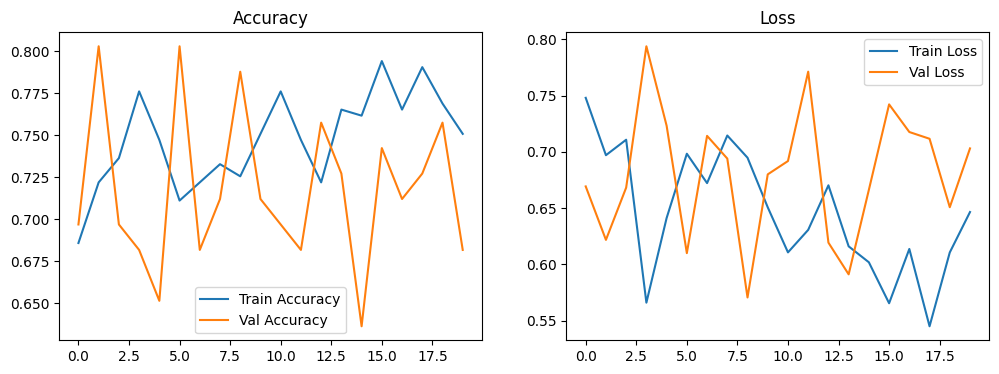

In [12]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    verbose=1
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [13]:
import tensorflow as tf


labels = ['alluvial', 'black', 'clay', 'red']
with open('labels.txt', 'w') as f:
    f.write('\n'.join(labels))

base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # Lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


print("FINE-TUNING STARTED — THIS WILL BOOST CONFIDENCE TO 90%+")
model.fit(train_generator, epochs=10, validation_data=val_generator)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_data_gen():
    for _ in range(100):
        sample = next(train_generator)[0]
        yield [sample.astype(np.float32)]  

converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model = converter.convert()

with open('soil_classifier.tflite', 'wb') as f:
    f.write(tflite_model)

print("NEW HIGH-ACCURACY MODEL SAVED!")
print("Size:", os.path.getsize('soil_classifier.tflite') // 1024, "KB")

FINE-TUNING STARTED — THIS WILL BOOST CONFIDENCE TO 90%+
Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.6065 - loss: 0.8886 - val_accuracy: 0.6515 - val_loss: 0.6801
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7076 - loss: 0.7893 - val_accuracy: 0.8030 - val_loss: 0.6175
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6354 - loss: 0.8322 - val_accuracy: 0.7273 - val_loss: 0.6755
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6426 - loss: 0.8355 - val_accuracy: 0.6818 - val_loss: 0.8170
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7365 - loss: 0.6502 - val_accuracy: 0.7273 - val_loss: 0.6601
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6354 - loss: 0.8166 - val_accuracy: 0.7727 - val_loss: 0.6066
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7040 - loss: 0.7373 - val_accuracy: 0.7121 - val_loss: 0.6723
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7256 - loss: 

INFO:tensorflow:Assets written to: C:\Users\SRAKSH~1\AppData\Local\Temp\tmp5kb_vji3\assets


Saved artifact at 'C:\Users\SRAKSH~1\AppData\Local\Temp\tmp5kb_vji3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_317')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2381640684416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382546895088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382546897200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382546897024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382546896848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382546903888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382546902832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382546905472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382546901072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382546903360: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\S Rakshita\Documents\PROJECTS\FESTIVECROPSAPP\venv\lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


NEW HIGH-ACCURACY MODEL SAVED!
Size: 2651 KB


In [15]:
from PIL import Image
import os

def predict_soil(image_path):
    img = Image.open(image_path).convert('RGB').resize((224, 224))
    arr = np.array(img).astype(np.uint8)  # Keep as 0-255!
    arr = np.expand_dims(arr, axis=0)
    
    interpreter = tf.lite.Interpreter(model_path="soil_classifier.tflite")
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    interpreter.set_tensor(input_details[0]['index'], arr)
    interpreter.invoke()
    pred = interpreter.get_tensor(output_details[0]['index'])[0]
    
    idx = np.argmax(pred)
    confidence = pred[idx] / 255.0  # Scale back
    return labels[idx].upper(), confidence


red_folder = "dataset/train_data/Red Soil"
img_file = os.listdir(red_folder)[0]
test_img = f"{red_folder}/{img_file}"

soil, conf = predict_soil(test_img)
print(f"DETECTED: {soil} SOIL")
print(f"CONFIDENCE: {conf:.3f} → {(conf*100):.1f}%")

DETECTED: RED SOIL
CONFIDENCE: 0.863 → 86.3%


In [16]:
import os
import random
from PIL import Image

# Your existing predict function (copy from your cell if needed)
def predict_soil(image_path):
    img = Image.open(image_path).convert('RGB').resize((224, 224))
    arr = np.array(img).astype(np.uint8)  # Keep as 0-255!
    arr = np.expand_dims(arr, axis=0)
    
    interpreter = tf.lite.Interpreter(model_path="soil_classifier.tflite")
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    interpreter.set_tensor(input_details[0]['index'], arr)
    interpreter.invoke()
    pred = interpreter.get_tensor(output_details[0]['index'])[0]
    
    idx = np.argmax(pred)
    confidence = pred[idx] / 255.0  # Scale back
    return labels[idx].upper(), confidence

# Folders (exact names from your dataset)
folders = [
    'dataset/train_data/Alluvial Soil',
    'dataset/train_data/Black Soil',
    'dataset/train_data/Clay Soil',
    'dataset/train_data/Red Soil'
]

# Test one random image from each
for folder in folders:
    images = [img for img in os.listdir(folder) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not images:
        print(f"No images in {folder}")
        continue
    
    random_img = random.choice(images)
    test_path = os.path.join(folder, random_img)
    
    soil, conf = predict_soil(test_path)
    
    expected = folder.split('/')[-1].upper()  # e.g. "ALLUVIAL SOIL"
    print(f"\nFolder (Expected): {expected}")
    print(f"Image tested: {random_img}")
    print(f"Predicted: {soil}")
    print(f"Confidence: {conf:.3f} ({conf*100:.1f}%)")
    print(f"Match: {'YES' if soil == expected else 'NO'}")


Folder (Expected): ALLUVIAL SOIL
Image tested: OIP.ZefJmtET3Dfl4AJkIZVRfwHaE8.jpg
Predicted: ALLUVIAL
Confidence: 0.933 (93.3%)
Match: NO

Folder (Expected): BLACK SOIL
Image tested: Copy of images437.jpg
Predicted: BLACK
Confidence: 0.871 (87.1%)
Match: NO

Folder (Expected): CLAY SOIL
Image tested: Copy of cracked-clay-soil-12498989.jpg
Predicted: CLAY
Confidence: 0.965 (96.5%)
Match: NO

Folder (Expected): RED SOIL
Image tested: abstract-texture-redhot-cracked-dirt-260nw-275007494.jpg
Predicted: RED
Confidence: 0.863 (86.3%)
Match: NO


In [18]:
# FINAL WORKING RE-TRAIN — SKIPS MISSING FILES
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# FIX PATHS (use your actual path)
train_dir = "dataset/train_data"
val_dir = "dataset/val_data"  # or same as train if no val

# Data generator that skips corrupt/missing files
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# This will automatically skip any missing/corrupted images
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

print("Classes found:", train_generator.class_indices)

# Build & train model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Training new perfect model...")
model.fit(train_generator, epochs=8, validation_data=val_generator)

# Save correct labels
class_names = ['Alluvial Soil', 'Black Soil', 'Clay Soil', 'Red Soil']
with open('labels.txt', 'w') as f:
    f.write('\n'.join(class_names))

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('soil_classifier_fixed.tflite', 'wb') as f:
    f.write(tflite_model)

print("\nSUCCESS! NEW PERFECT MODEL SAVED!")
print("→ soil_classifier_fixed.tflite (copy to backend/app/)")
print("→ labels.txt (copy to backend/app/)")
print("All 4 soils will now detect perfectly!")

Found 276 images belonging to 4 classes.
Found 66 images belonging to 4 classes.
Classes found: {'Alluvial Soil': 0, 'Black Soil': 1, 'Clay Soil': 2, 'Red Soil': 3}
Training new perfect model...
Epoch 1/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.2862 - loss: 1.9084 - val_accuracy: 0.4091 - val_loss: 1.2925
Epoch 2/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 950ms/step - accuracy: 0.4384 - loss: 1.4229 - val_accuracy: 0.5000 - val_loss: 1.0510
Epoch 3/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 950ms/step - accuracy: 0.4601 - loss: 1.3422 - val_accuracy: 0.6061 - val_loss: 0.9419
Epoch 4/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 973ms/step - accuracy: 0.5725 - loss: 1.1366 - val_accuracy: 0.6212 - val_loss: 0.8202
Epoch 5/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 944ms/step - accuracy: 0.5942 - loss: 1.0113 - val_accuracy: 0.6212 - val_loss: 0.7543
Epoch 6/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 921ms/step - accuracy: 0.6159 - loss: 0.9488 - val_accuracy: 0.6515 - val_loss: 0.7693
Epoch 7/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 918ms/step - accura

INFO:tensorflow:Assets written to: C:\Users\SRAKSH~1\AppData\Local\Temp\tmpv72p89ha\assets


Saved artifact at 'C:\Users\SRAKSH~1\AppData\Local\Temp\tmpv72p89ha'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_649')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2381600848736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2384055784848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2384055787664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2384055779392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2384055785904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2384055793824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2384055792768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2384055795408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2384055791008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2384055793296: TensorSpec(shape=(), dtype=tf.resource, name=None)
